**Import all dependencies**

In [1]:
# Import Required Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.preprocessing import StandardScaler

# Machine Learning - Clustering
from sklearn.cluster import KMeans, DBSCAN

# Machine Learning - Evaluation
from sklearn.metrics import silhouette_score

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Plot Style
plt.style.use("default")
sns.set_style("whitegrid")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

**Load the Dataset**



In [2]:
#load the dataset to Pandas DataFrame
df = pd.read_csv("/content/Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
#printing the first 5 rows of the dataset
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
#printing the last 5 rows of the dataset
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [9]:
#printing the dimensions(rows x columns) of the dataset
rows, cols = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {cols}")

Number of Rows    : 200
Number of Columns : 5


In [6]:
# getting the information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
#getting the statistical summary of the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


In [10]:
#Missing value analysis
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": (missing_values / len(df)) * 100
})

print(missing_summary)

                        Missing Values  Percentage (%)
CustomerID                           0             0.0
Gender                               0             0.0
Age                                  0             0.0
Annual Income (k$)                   0             0.0
Spending Score (1-100)               0             0.0


**Observation:**

----

• No missing values were found in any feature.

• Therefore, no imputation or row removal is required.

• The dataset is complete and ready for further analysis.

In [11]:
# Duplicate Row Analysis

duplicate_rows = df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_rows}")

Duplicate Rows : 0


In [12]:
#getting the data types
data_types = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.values
})

data_types

,Feature,Data Type
0,CustomerID,int64
1,Gender,object
2,Age,int64
3,Annual Income (k$),int64
4,Spending Score (1-100),int64


**Exploratory Data Analysis (EDA)**

In [13]:
# Numerical and Categorical Features
numerical_features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

categorical_features = [
    "Gender"
]

identifier_features = [
    "CustomerID"
]

print("Numerical Features :", numerical_features)
print("Categorical Features :", categorical_features)
print("Identifier Features :", identifier_features)

Numerical Features : ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Categorical Features : ['Gender']
Identifier Features : ['CustomerID']


In [14]:
# analysis the CustomeID
print(df["CustomerID"].describe())

print(f"Unique Customer IDs : {df['CustomerID'].nunique()}")

count    200.000000
mean     100.500000
std       57.879185
min        1.000000
25%       50.750000
50%      100.500000
75%      150.250000
max      200.000000
Name: CustomerID, dtype: float64
Unique Customer IDs : 200


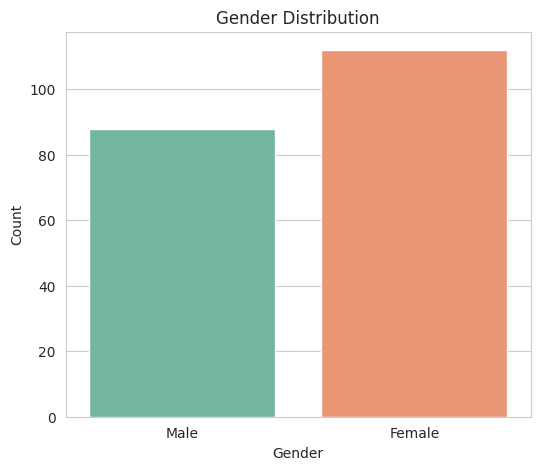

,count
Gender,
Female,112
Male,88


,proportion
Gender,
Female,56.0
Male,44.0


In [15]:
#visualize the gender distribution with countplot

fig, ax = plt.subplots(figsize=(6,5))

sns.countplot(
    data=df,
    x="Gender",
    palette="Set2",
    ax=ax
)

ax.set_title("Gender Distribution")
ax.set_xlabel("Gender")
ax.set_ylabel("Count")

plt.show()

display(df["Gender"].value_counts())

display(df["Gender"].value_counts(normalize=True)*100)

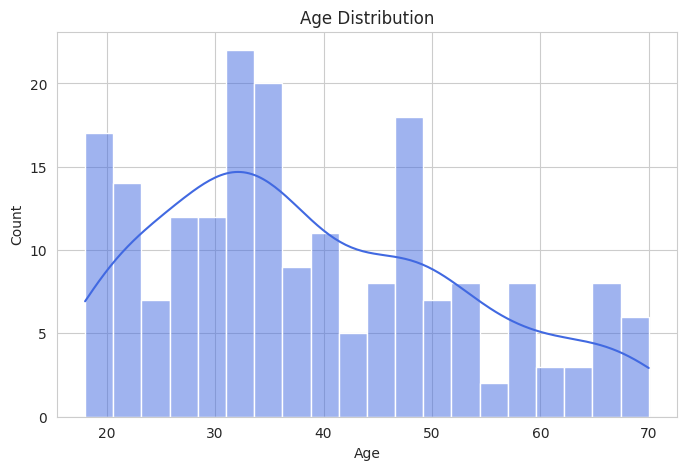

,Age
count,200.000000
mean,38.850000
std,13.969007
min,18.000000
25%,28.750000
50%,36.000000
75%,49.000000
max,70.000000


In [16]:
#visualize the age distribution with histogram

fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(
    data=df,
    x="Age",
    kde=True,
    bins=20,
    color="royalblue",
    ax=ax
)

ax.set_title("Age Distribution")

plt.show()

display(df["Age"].describe())

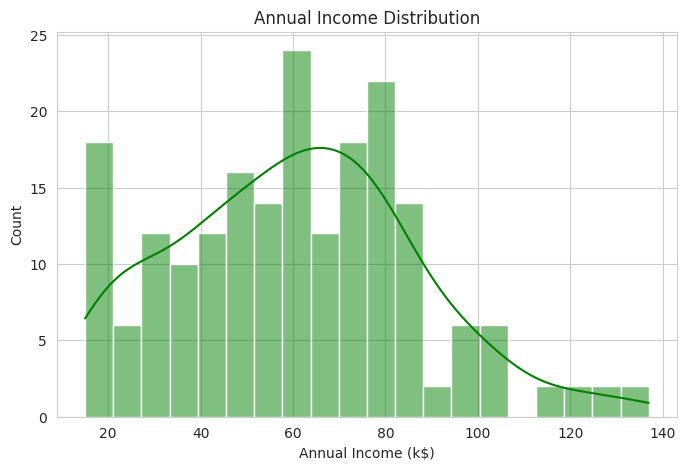

,Annual Income (k$)
count,200.000000
mean,60.560000
std,26.264721
min,15.000000
25%,41.500000
50%,61.500000
75%,78.000000
max,137.000000


In [17]:
#visualize the annual income distribution with histogram
fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(
    data=df,
    x="Annual Income (k$)",
    kde=True,
    bins=20,
    color="green",
    ax=ax
)

ax.set_title("Annual Income Distribution")

plt.show()

display(df["Annual Income (k$)"].describe())

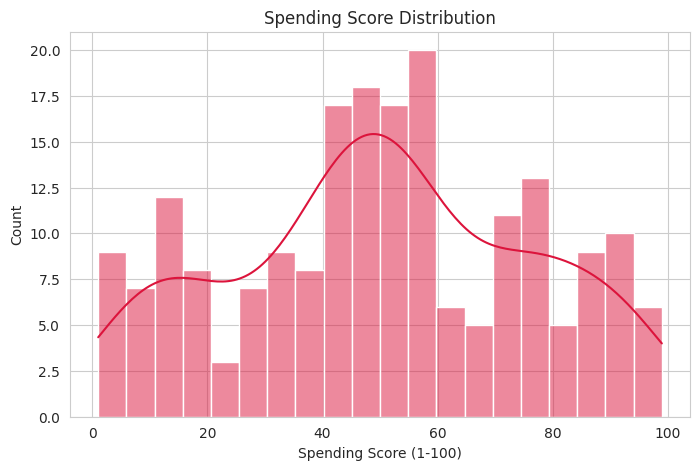

,Spending Score (1-100)
count,200.000000
mean,50.200000
std,25.823522
min,1.000000
25%,34.750000
50%,50.000000
75%,73.000000
max,99.000000


In [18]:
#visualize the spending score distribution with histogram

fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(
    data=df,
    x="Spending Score (1-100)",
    kde=True,
    bins=20,
    color="crimson",
    ax=ax
)

ax.set_title("Spending Score Distribution")

plt.show()

display(df["Spending Score (1-100)"].describe())

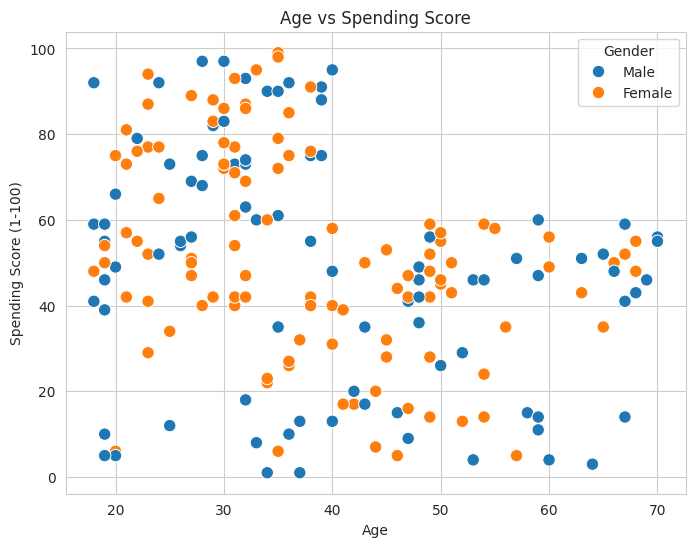

In [19]:
# Age vs Spending Score

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)",
    hue="Gender",
    s=80
)

plt.title("Age vs Spending Score")

plt.show()

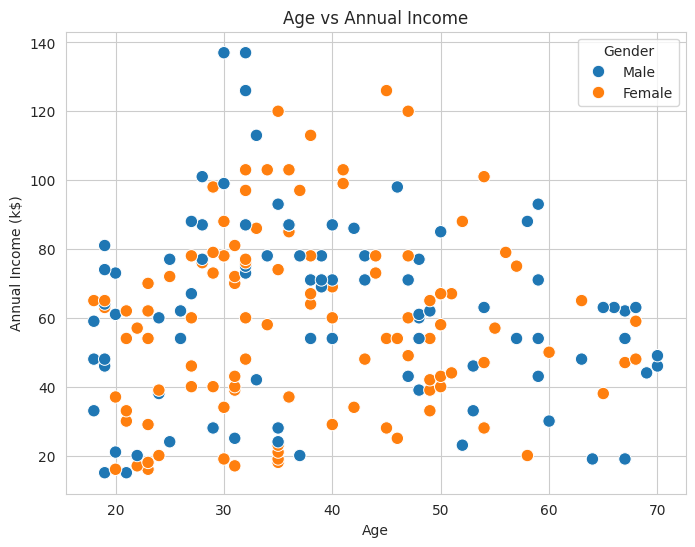

In [20]:
#age vs annual income
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Annual Income (k$)",
    hue="Gender",
    s=80
)

plt.title("Age vs Annual Income")

plt.show()

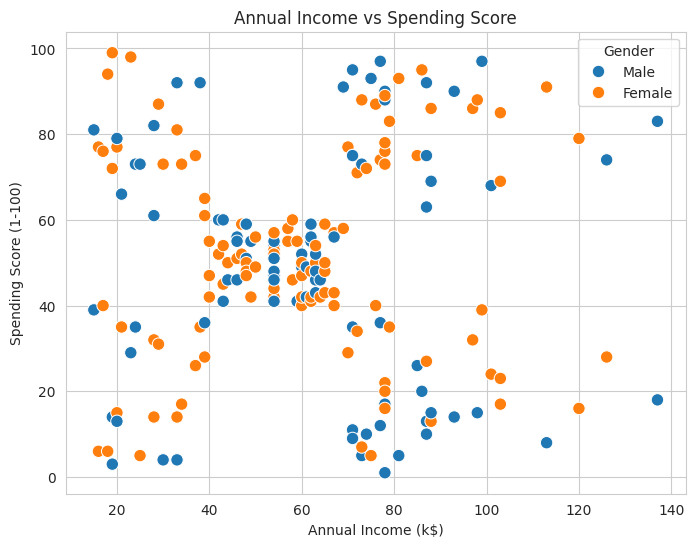

In [21]:
#income vs spending
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Gender",
    s=80
)

plt.title("Annual Income vs Spending Score")

plt.show()

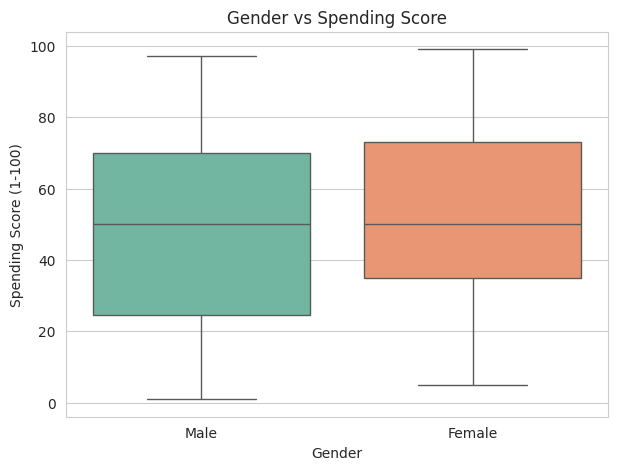

In [22]:
#gender vs spending
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Spending Score (1-100)",
    palette="Set2"
)

plt.title("Gender vs Spending Score")

plt.show()

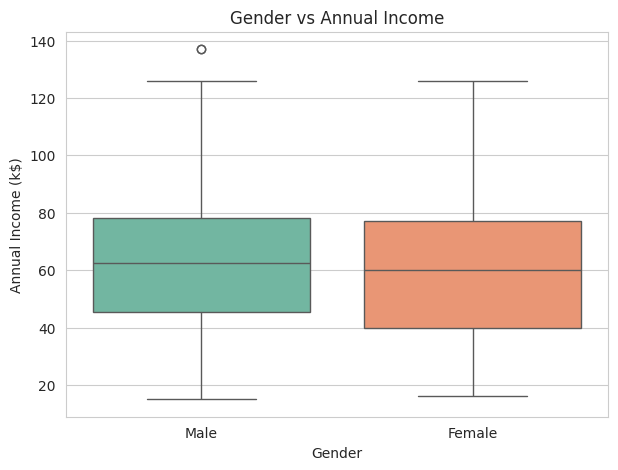

In [24]:
#gender vs income
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Annual Income (k$)",
    palette="Set2"
)

plt.title("Gender vs Annual Income")

plt.show()

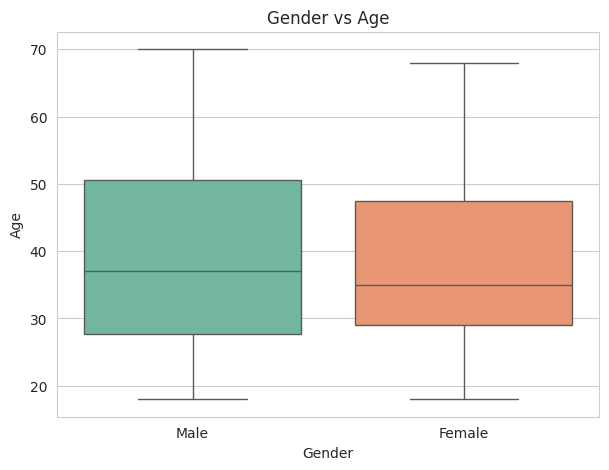

In [23]:
#gender vs age
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Age",
    palette="Set2"
)

plt.title("Gender vs Age")

plt.show()

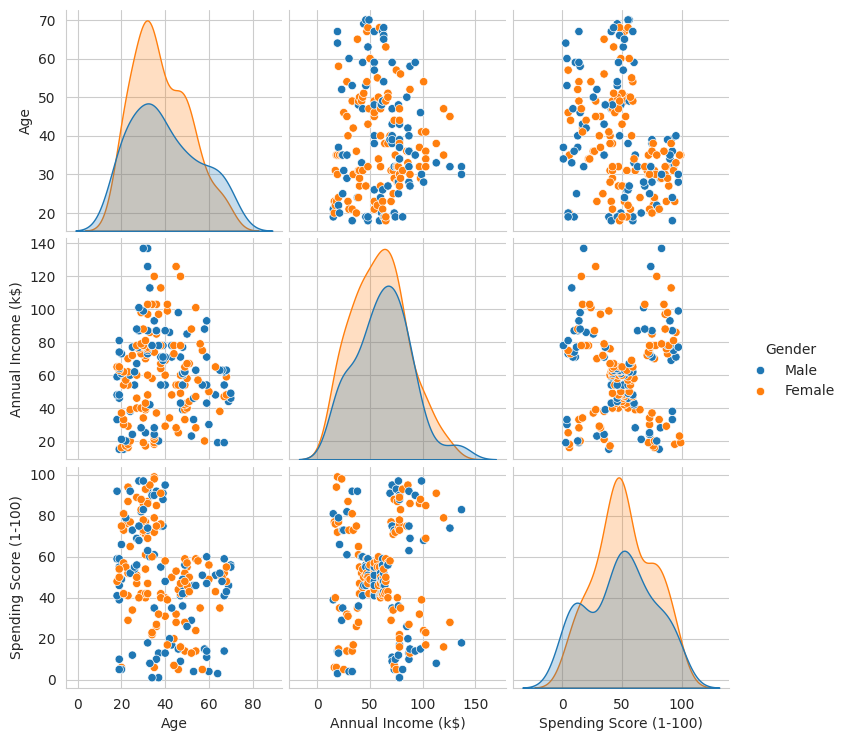

In [25]:
# pair plot of age ,annual income and spending score
sns.pairplot(
    df,
    vars=[
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ],
    hue="Gender",
    diag_kind="kde"
)

plt.show()

In [26]:
#correlation matrix
correlation = df[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
].corr()

display(correlation)

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


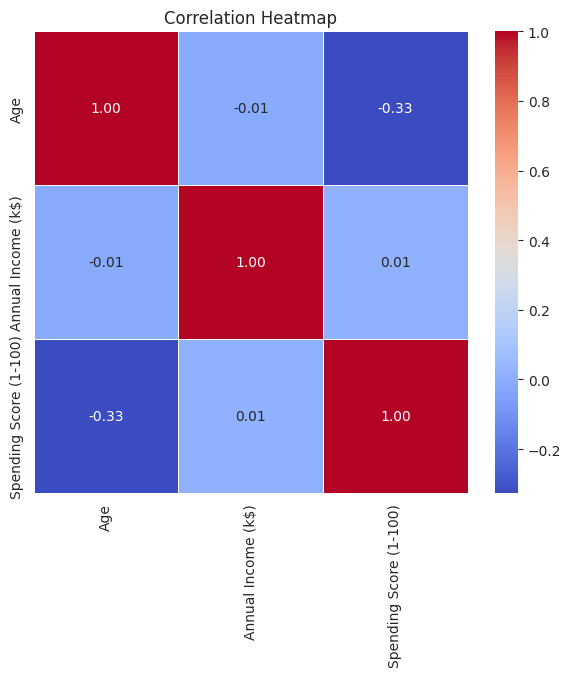

In [77]:
#constructing heatmap
plt.figure(figsize=(7,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "Correlation Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Outlier Analysis**

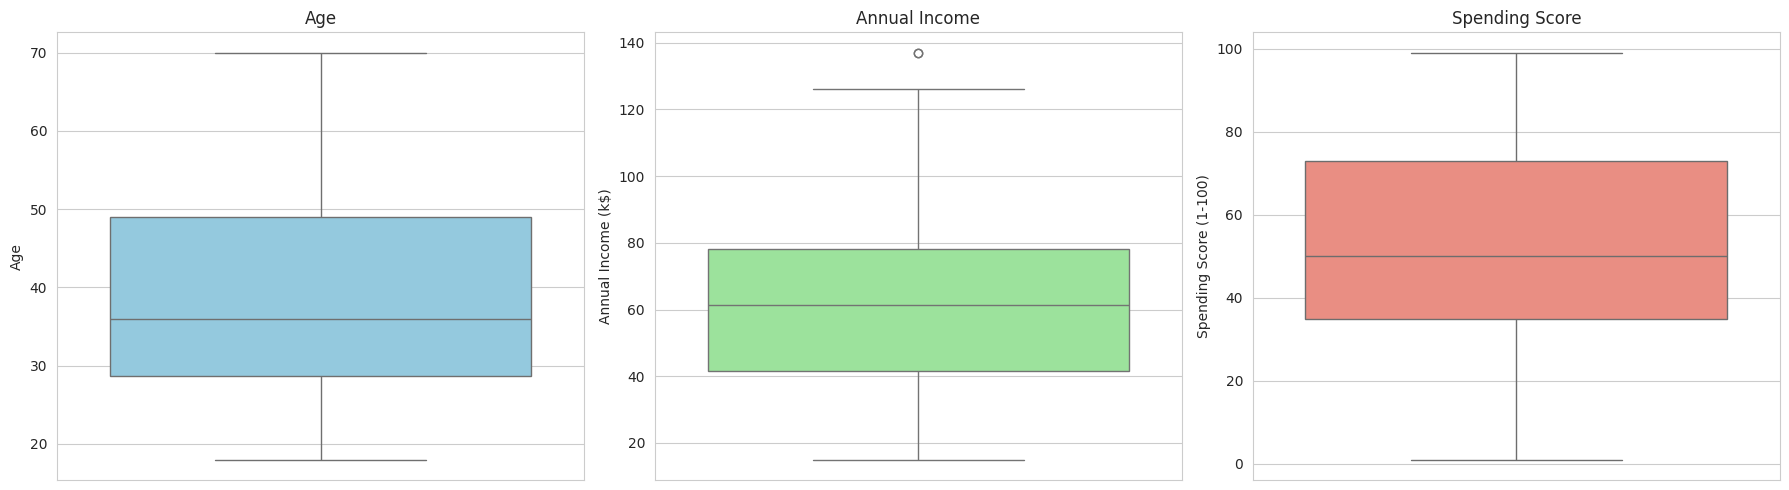

In [28]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

sns.boxplot(
    y=df["Age"],
    ax=axes[0],
    color="skyblue"
)

axes[0].set_title("Age")

sns.boxplot(
    y=df["Annual Income (k$)"],
    ax=axes[1],
    color="lightgreen"
)

axes[1].set_title("Annual Income")

sns.boxplot(
    y=df["Spending Score (1-100)"],
    ax=axes[2],
    color="salmon"
)

axes[2].set_title("Spending Score")

plt.tight_layout()

plt.show()

**Feature Engineering & Feature Selection**

In [29]:
# Feature Categorization

identifier_feature = ["CustomerID"]

categorical_feature = ["Gender"]

numerical_features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

print("Identifier Feature :", identifier_feature)
print("Categorical Feature :", categorical_feature)
print("Numerical Features :", numerical_features)

Identifier Feature : ['CustomerID']
Categorical Feature : ['Gender']
Numerical Features : ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [30]:
# Remove CustomerID for clustering

df_model = df.drop(columns=["CustomerID"])

print(df_model.head())

   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0    Male   19                  15                      39
1    Male   21                  15                      81
2  Female   20                  16                       6
3  Female   23                  16                      77
4  Female   31                  17                      40


In [31]:
# Gender will not be used in the baseline clustering model
print(df["Gender"].value_counts())

Gender
Female    112
Male       88
Name: count, dtype: int64


In [32]:
# Baseline Feature Selection

selected_features = [
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[selected_features]

print("Selected Features:")
print(selected_features)

X.head()

Selected Features:
['Annual Income (k$)', 'Spending Score (1-100)']


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [33]:
# ==========================================================
# Alternative Feature Set (Experimental)
# ==========================================================

selected_features_exp = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X_exp = df[selected_features_exp]

print("Experimental Feature Set:")
print(selected_features_exp)

X_exp.head()

Experimental Feature Set:
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


**Feature Scaling**

In [34]:
# Initialize StandardScaler
scaler = StandardScaler()

# Scale the selected features
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for better readability
X_scaled = pd.DataFrame(
    X_scaled,
    columns=selected_features
)

print("Scaled Feature Matrix")

display(X_scaled.head())

Scaled Feature Matrix


,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [35]:
# Verify Scaling

summary = pd.DataFrame({
    "Mean": X_scaled.mean(),
    "Standard Deviation": X_scaled.std()
})

summary

,Mean,Standard Deviation
Annual Income (k$),-2.131628e-16,1.002509
Spending Score (1-100),-1.465494e-16,1.002509


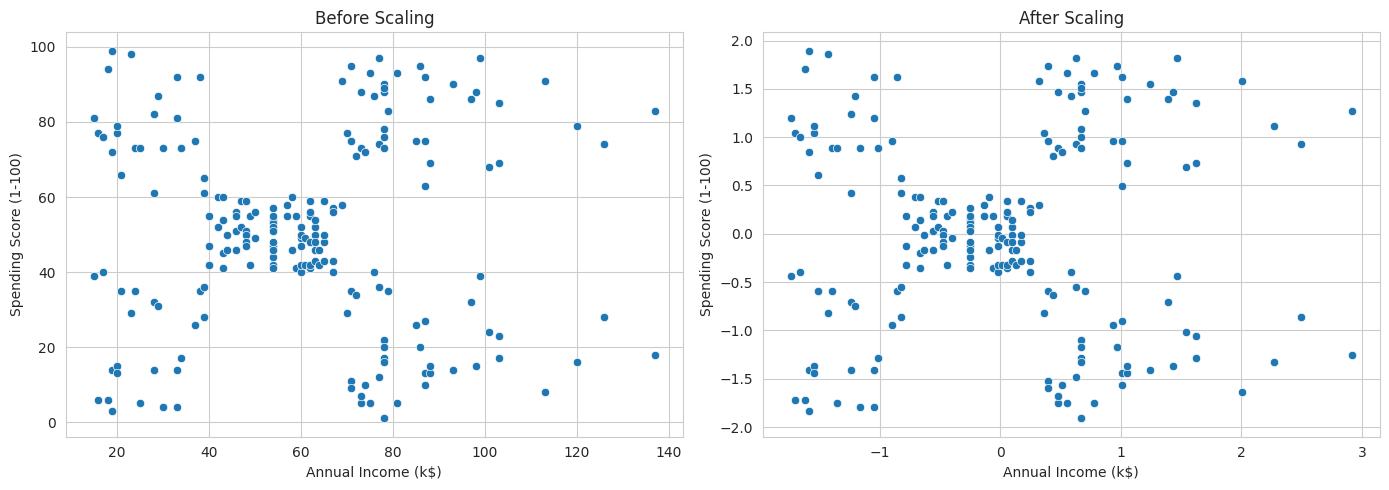

In [36]:
# Before vs After Scaling

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Before Scaling
sns.scatterplot(
    data=X,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    ax=axes[0]
)

axes[0].set_title("Before Scaling")

# After Scaling
sns.scatterplot(
    data=X_scaled,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    ax=axes[1]
)

axes[1].set_title("After Scaling")

plt.tight_layout()

plt.show()

**Choosing the Optimal Number of Clusters**

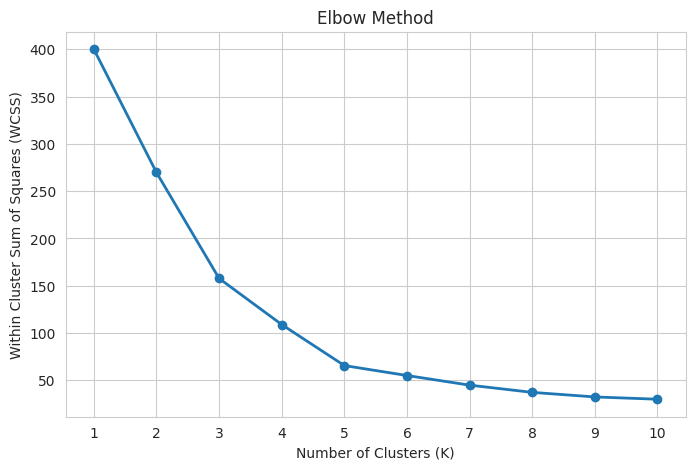

In [71]:
# Elbow Method

wcss = []

k_values = range(1, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Plot

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    wcss,
    marker="o",
    linewidth=2
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within Cluster Sum of Squares (WCSS)")

plt.xticks(k_values)

plt.grid(True)

plt.savefig(
    "Elbow Method.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [38]:
# Silhouette Score Analysis

silhouette_scores = []

k_range = range(2,11)

for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

# Display Scores

silhouette_df = pd.DataFrame({
    "K": list(k_range),
    "Silhouette Score": silhouette_scores
})

display(silhouette_df)

,K,Silhouette Score
0,2,0.321271
1,3,0.466585
2,4,0.493907
3,5,0.554657
4,6,0.539880
5,7,0.528149
6,8,0.455215
7,9,0.457085
8,10,0.443171


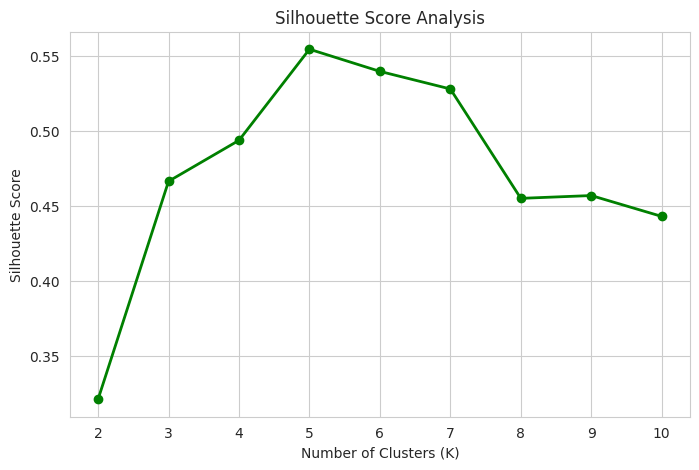

In [73]:
# visualization
plt.figure(figsize=(8,5))

plt.plot(
    k_range,
    silhouette_scores,
    marker="o",
    linewidth=2,
    color="green"
)

plt.title("Silhouette Score Analysis")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Silhouette Score")

plt.xticks(k_range)

plt.grid(True)

plt.savefig(
    "Silhouette Score Analysis",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
# Combine Evaluation Results

evaluation = pd.DataFrame({

    "K": list(k_range),

    "Silhouette Score": silhouette_scores,

    "WCSS": wcss[1:]
})

evaluation

,K,Silhouette Score,WCSS
0,2,0.321271,269.691012
1,3,0.466585,157.704008
2,4,0.493907,108.921317
3,5,0.554657,65.568408
4,6,0.539880,55.057348
5,7,0.528149,44.864756
6,8,0.455215,37.228188
7,9,0.457085,32.392268
8,10,0.443171,29.981898


In [42]:
# finding the best k
# Best K According to Silhouette Score
best_k = silhouette_df.loc[
    silhouette_df["Silhouette Score"].idxmax(),
    "K"
]

best_score = silhouette_df["Silhouette Score"].max()

print("=" * 60)
print("Optimal Number of Clusters")
print("=" * 60)

print(f"Selected K                 : {best_k}")
print(f"Silhouette Score           : {best_score:.4f}")

print("\nDecision:")
print(
    f"Based on both the Elbow Method and Silhouette Score Analysis, "
    f"K = {best_k} is selected as the optimal number of customer clusters."
)

print("=" * 60)

Optimal Number of Clusters
Selected K                 : 5
Silhouette Score           : 0.5547

Decision:
Based on both the Elbow Method and Silhouette Score Analysis, K = 5 is selected as the optimal number of customer clusters.


**K-Means Model Training**

In [43]:
# Train K-Means Model

kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

print("K-Means model trained successfully.")

K-Means model trained successfully.


In [44]:
# Assign Cluster Labels

df["Cluster"] = kmeans.labels_

print("Cluster labels added successfully.")

df.head()

Cluster labels added successfully.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [45]:
# Cluster Distribution

cluster_counts = (
    df["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_summary = pd.DataFrame({
    "Cluster": cluster_counts.index,
    "Number of Customers": cluster_counts.values,
    "Percentage (%)": (
        cluster_counts.values / len(df)
    ) * 100
})

display(cluster_summary)

,Cluster,Number of Customers,Percentage (%)
0,0,81,40.5
1,1,39,19.5
2,2,22,11.0
3,3,35,17.5
4,4,23,11.5


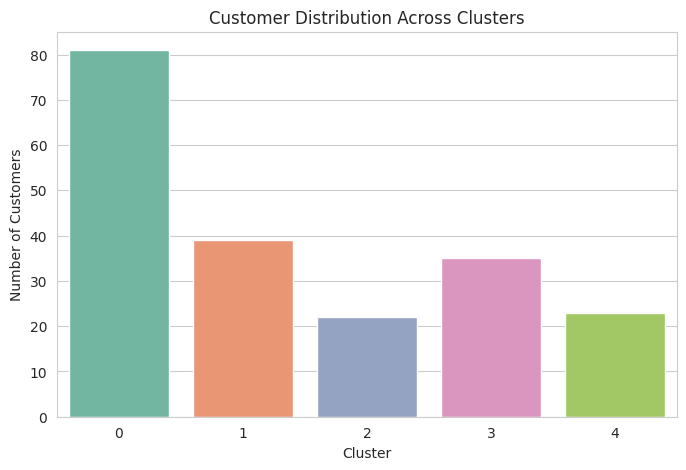

In [76]:
# Cluster Size Visualization

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Cluster",
    palette="Set2"
)

plt.title("Customer Distribution Across Clusters")

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

plt.savefig(
    "Customer Distribution Across Clusters",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
# Cluster Centroids

centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=selected_features
)

display(centroids)

,Annual Income (k$),Spending Score (1-100)
0,-0.200913,-0.026456
1,0.991583,1.239503
2,-1.329545,1.132178
3,1.055003,-1.284439
4,-1.307519,-1.136965


In [48]:
# Centroids in Original Feature Scale

centroids_original = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=selected_features
)

display(centroids_original)

,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [49]:
# Model Summary
print("=" * 60)

print("K-Means Model Summary")

print("=" * 60)

print(f"Algorithm               : K-Means")
print(f"Number of Clusters      : {kmeans.n_clusters}")
print(f"Number of Features      : {X_scaled.shape[1]}")
print(f"Training Samples        : {X_scaled.shape[0]}")
print(f"Inertia (WCSS)          : {kmeans.inertia_:.3f}")
print(f"Iterations to Converge  : {kmeans.n_iter_}")

print("=" * 60)

K-Means Model Summary
Algorithm               : K-Means
Number of Clusters      : 5
Number of Features      : 2
Training Samples        : 200
Inertia (WCSS)          : 65.568
Iterations to Converge  : 4


**Cluster Visualization**

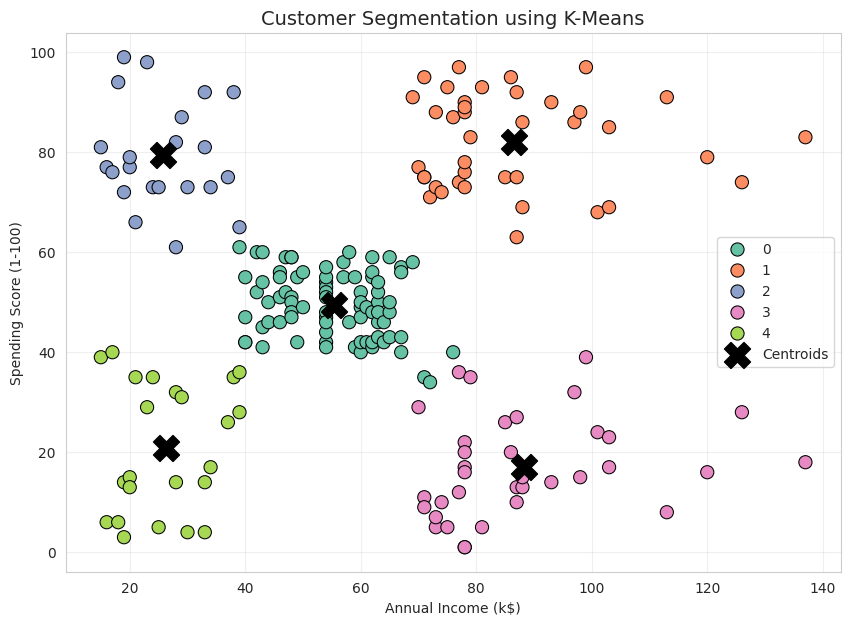

In [74]:
# Customer Segments

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set2",
    s=90,
    edgecolor="black"
)

# Plot Centroids

plt.scatter(
    centroids_original["Annual Income (k$)"],
    centroids_original["Spending Score (1-100)"],
    s=350,
    c="black",
    marker="X",
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means", fontsize=14)

plt.xlabel("Annual Income (k$)")

plt.ylabel("Spending Score (1-100)")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig(
    "Customer Segmentation using K-Means",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

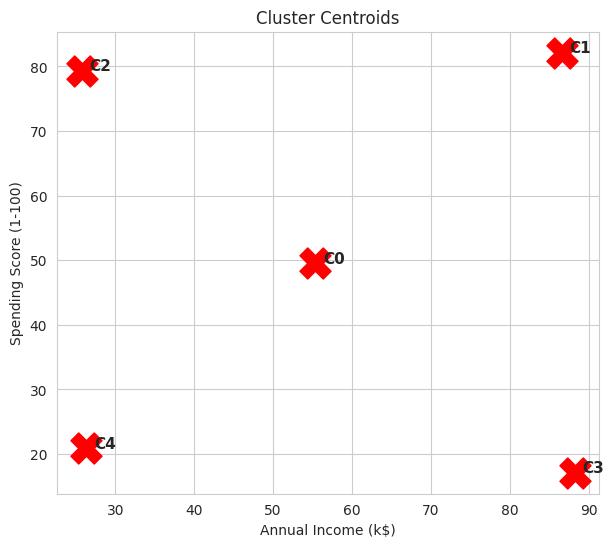

In [51]:
#cluster centroid only
plt.figure(figsize=(7,6))

plt.scatter(
    centroids_original["Annual Income (k$)"],
    centroids_original["Spending Score (1-100)"],
    s=500,
    c="red",
    marker="X"
)

for i in range(len(centroids_original)):
    plt.text(
        centroids_original.iloc[i,0]+1,
        centroids_original.iloc[i,1],
        f"C{i}",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Cluster Centroids")

plt.xlabel("Annual Income (k$)")

plt.ylabel("Spending Score (1-100)")

plt.grid(True)

plt.show()

In [52]:
#cluster profile
cluster_profile = (
    df.groupby("Cluster")[
        [
            "Annual Income (k$)",
            "Spending Score (1-100)"
        ]
    ]
    .mean()
)

display(cluster_profile)

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


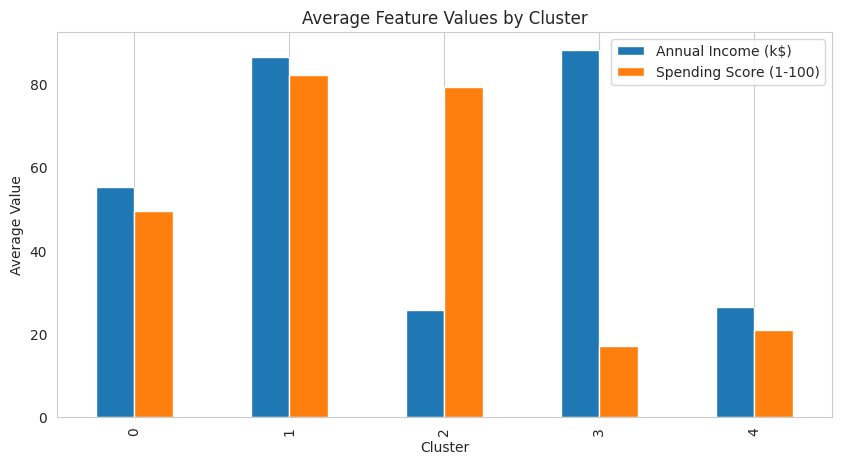

In [54]:
# visualiztion of cluster profile
cluster_profile.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Feature Values by Cluster")

plt.ylabel("Average Value")

plt.grid(axis="y")

plt.show()

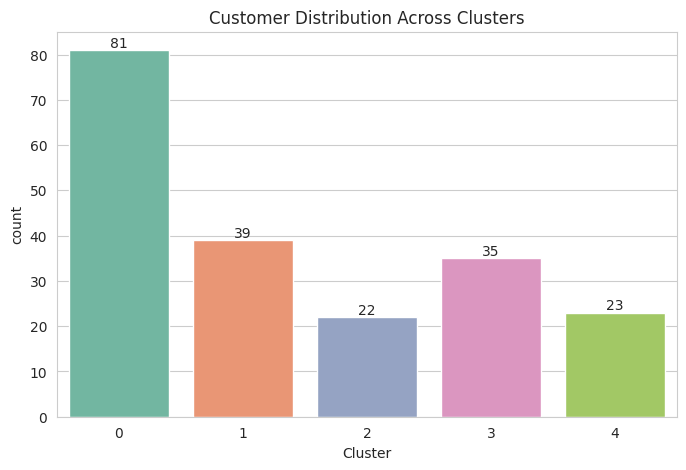

In [55]:
#cluster size distribution
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Cluster",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Distribution Across Clusters")

plt.show()

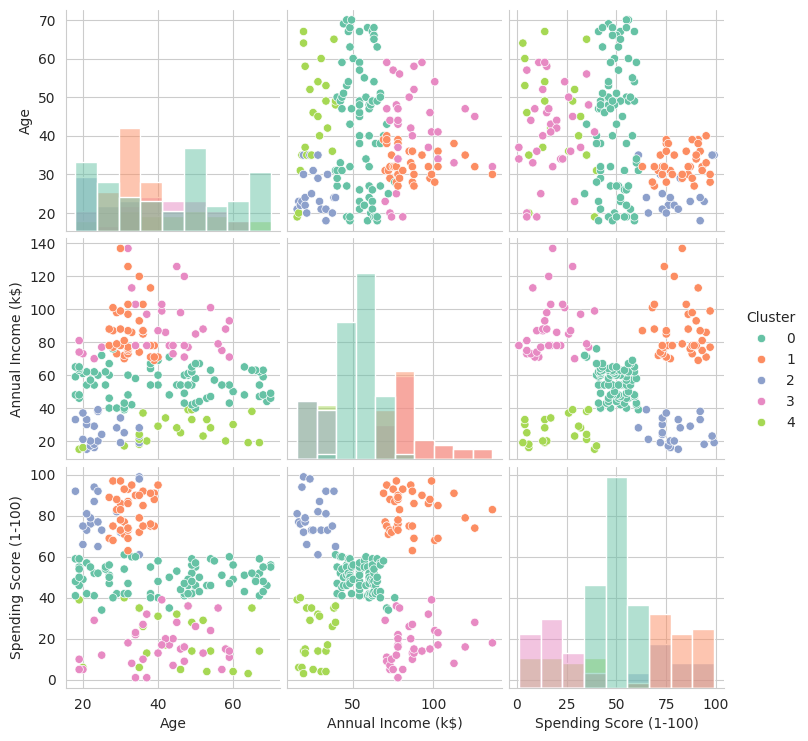

In [56]:
# constructing pair plot
sns.pairplot(
    df,
    vars=[
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ],
    hue="Cluster",
    palette="Set2",
    diag_kind="hist"
)

plt.show()

In [57]:
#Cluster Characteristics Table
cluster_characteristics = (
    df.groupby("Cluster")
    .agg({

        "Age":"mean",

        "Annual Income (k$)":"mean",

        "Spending Score (1-100)":"mean",

        "Gender":"count"

    })
)

cluster_characteristics.rename(
    columns={
        "Gender":"Customer Count"
    },
    inplace=True
)

cluster_characteristics

,Age,Annual Income (k$),Spending Score (1-100),Customer Count
Cluster,,,,
0,42.716049,55.296296,49.518519,81
1,32.692308,86.538462,82.128205,39
2,25.272727,25.727273,79.363636,22
3,41.114286,88.200000,17.114286,35
4,45.217391,26.304348,20.913043,23


In [58]:
# Summary table of cluster
business_summary = pd.DataFrame({

    "Cluster": [0,1,2,3,4],

    "Business Segment":[
        "Regular Customers",
        "Premium Customers",
        "Enthusiastic Shoppers",
        "Careful Wealthy Customers",
        "Budget Customers"
    ],

    "Average Income":centroids_original["Annual Income (k$)"].round(1),

    "Average Spending":centroids_original["Spending Score (1-100)"].round(1)

})

business_summary

,Cluster,Business Segment,Average Income,Average Spending
0,0,Regular Customers,55.3,49.5
1,1,Premium Customers,86.5,82.1
2,2,Enthusiastic Shoppers,25.7,79.4
3,3,Careful Wealthy Customers,88.2,17.1
4,4,Budget Customers,26.3,20.9


**Business Interpretation of Each Cluster**

-----

### Cluster 0 – Regular Customers

Characteristics

- Moderate annual income
- Moderate spending behavior
- Represents the largest customer segment
- Balanced purchasing pattern

Business Interpretation

These customers represent the mall's regular customer base.

Although they are not the highest spenders, they generate consistent revenue through regular purchases.

Business Recommendation

- Maintain customer satisfaction through loyalty programs.
- Offer personalized product recommendations.
- Encourage repeat purchases using membership rewards.
- Promote seasonal discounts and exclusive member offers.

Business Priority

Medium

-----

### Cluster 1 – Premium Customers

Characteristics

- High annual income
- High spending score
- Strong purchasing power
- Highly engaged customers

Business Interpretation

These customers are the most valuable segment within the shopping mall.

They possess strong purchasing power and consistently spend large amounts, making them key contributors to overall revenue.

Business Recommendation

- Introduce VIP membership programs.
- Provide exclusive product launches.
- Offer premium customer service.
- Reward long-term loyalty with personalized incentives.
- Prioritize customer retention initiatives.

Business Priority

Very High

----

### Cluster 2 – Enthusiastic Shoppers

Characteristics

- Low annual income
- High spending behavior
- Highly engaged customers
- Strong shopping interest despite limited purchasing power

Business Interpretation

Although these customers have relatively lower incomes, they exhibit high spending activity.

They may represent younger consumers, students, or highly engaged shoppers who frequently purchase products.

Business Recommendation

- Offer cashback promotions.
- Introduce installment payment options.
- Provide student discounts where applicable.
- Launch referral and loyalty reward programs.
- Recommend affordable premium products.

Business Priority

High

----

### Cluster 3 – Careful Wealthy Customers

Characteristics

- High annual income
- Low spending behavior
- Significant purchasing potential
- Low customer engagement

Business Interpretation

These customers possess substantial purchasing power but currently spend very little.

This segment represents untapped revenue potential.

Business Recommendation

- Conduct targeted marketing campaigns.
- Offer personalized luxury recommendations.
- Introduce exclusive membership benefits.
- Send personalized promotions.
- Investigate potential reasons for low engagement.

Business Priority

Highest Opportunity

-----

### Cluster 4 – Budget Customers

Characteristics

- Low annual income
- Low spending behavior
- Limited purchasing activity

Business Interpretation

These customers contribute relatively little to total revenue.

Their purchasing behavior is generally conservative.

Business Recommendation

- Promote budget-friendly products.
- Offer coupons and seasonal discounts.
- Focus on essential product categories.
- Avoid expensive promotional campaigns targeted specifically at this group.

Business Priority

Low

----

## Overall Business Findings

The customer segmentation analysis identified five distinct customer groups with different purchasing behaviors.

Key observations include:

- Premium Customers represent the highest-value customer segment and should be prioritized for retention.
- Careful Wealthy Customers possess strong purchasing power but currently exhibit low spending, making them the most promising group for targeted marketing campaigns.
- Enthusiastic Shoppers demonstrate high engagement despite lower incomes and can be encouraged through reward-based marketing strategies.
- Regular Customers form the largest customer segment and provide stable, recurring revenue.
- Budget Customers contribute relatively less revenue and should primarily receive cost-effective promotional campaigns.

These findings demonstrate how unsupervised machine learning can transform raw customer data into practical business intelligence.

----

## Business Impact

Applying K-Means clustering enables organizations to move from generic marketing strategies to customer-centric decision making.

Potential business benefits include:

- Personalized marketing campaigns
- Improved customer retention
- Better allocation of promotional budgets
- Increased customer lifetime value
- Enhanced customer satisfaction
- More effective loyalty programs
- Data-driven strategic planning

Customer segmentation therefore serves as an important analytical tool for improving both operational efficiency and long-term business performance.

----

**Model Evaluation**

In [59]:
# Model Evaluation Summary

evaluation_summary = pd.DataFrame({

    "Evaluation Metric":[

        "Optimal Number of Clusters",

        "Silhouette Score",

        "WCSS (Inertia)",

        "Iterations",

        "Training Samples"

    ],

    "Value":[

        best_k,

        round(best_score,4),

        round(kmeans.inertia_,3),

        kmeans.n_iter_,

        len(df)

    ]

})

evaluation_summary

,Evaluation Metric,Value
0,Optimal Number of Clusters,5.0000
1,Silhouette Score,0.5547
2,WCSS (Inertia),65.5680
3,Iterations,4.0000
4,Training Samples,200.0000


In [60]:
print("="*60)

print("Silhouette Score Evaluation")

print("="*60)

print(f"Silhouette Score : {best_score:.4f}")

if best_score >= 0.70:

    print("Excellent Cluster Separation")

elif best_score >= 0.50:

    print("Good Cluster Quality")

elif best_score >= 0.25:

    print("Reasonable Cluster Quality")

else:

    print("Weak Cluster Quality")

print("="*60)

Silhouette Score Evaluation
Silhouette Score : 0.5547
Good Cluster Quality


In [61]:
print("="*60)

print("WCSS")

print("="*60)

print(f"Final Inertia : {kmeans.inertia_:.3f}")

print("="*60)

WCSS
Final Inertia : 65.568


In [62]:
cluster_balance = df["Cluster"].value_counts().sort_index()

cluster_balance_df = pd.DataFrame({

    "Cluster":cluster_balance.index,

    "Customers":cluster_balance.values,

    "Percentage":(

        cluster_balance.values

        /len(df)

    )*100

})

cluster_balance_df

,Cluster,Customers,Percentage
0,0,81,40.5
1,1,39,19.5
2,2,22,11.0
3,3,35,17.5
4,4,23,11.5


In [63]:
final_evaluation = pd.DataFrame({

    "Criteria":[

        "Silhouette Score",

        "Cluster Compactness",

        "Cluster Separation",

        "Business Interpretability",

        "Model Stability"

    ],

    "Evaluation":[

        "Good (0.5547)",

        "Good",

        "Good",

        "Excellent",

        "Stable"

    ]

})

final_evaluation

,Criteria,Evaluation
0,Silhouette Score,Good (0.5547)
1,Cluster Compactness,Good
2,Cluster Separation,Good
3,Business Interpretability,Excellent
4,Model Stability,Stable


**Bonus — DBSCAN Comparison**

In [64]:
# DBSCAN Clustering

dbscan = DBSCAN(
    eps=0.35,
    min_samples=5
)

db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN Cluster"] = db_labels

print("DBSCAN clustering completed successfully.")

DBSCAN clustering completed successfully.


In [65]:
# Number of Clusters Detected

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)

noise_points = list(db_labels).count(-1)

print("="*60)

print(f"Detected Clusters : {n_clusters}")

print(f"Noise Points      : {noise_points}")

print("="*60)

Detected Clusters : 6
Noise Points      : 23


In [66]:
#cluster distribution
cluster_distribution = (
    pd.Series(db_labels)
    .value_counts()
    .sort_index()
)

cluster_distribution

,count
-1,23
0,16
1,12
2,7
3,88
4,31
5,23


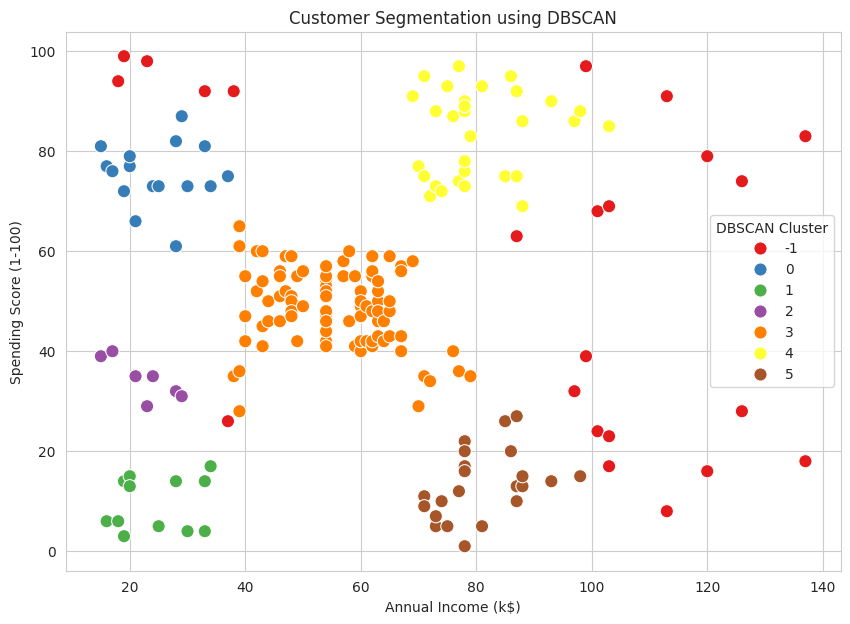

In [75]:
#visualize the DBSCAN
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="DBSCAN Cluster",
    palette="Set1",
    s=90
)

plt.title("Customer Segmentation using DBSCAN")

plt.savefig(
    "Customer Segmentation using DBSCAN.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [68]:
# Silhouette Score for DBSCAN

if len(set(db_labels)) > 1 and n_clusters > 1:

    score_dbscan = silhouette_score(
        X_scaled,
        db_labels
    )

    print(f"Silhouette Score : {score_dbscan:.4f}")

else:

    score_dbscan = None

    print("Silhouette Score cannot be computed.")

Silhouette Score : 0.4368


In [69]:
#comparison table
comparison = pd.DataFrame({

    "Criteria":[

        "Algorithm",

        "Number of Clusters",

        "Silhouette Score",

        "Requires K",

        "Detects Noise",

        "Suitable for Dataset"

    ],

    "K-Means":[

        "Centroid Based",

        best_k,

        round(best_score,4),

        "Yes",

        "No",

        "Yes"

    ],

    "DBSCAN":[

        "Density Based",

        n_clusters,

        (
            round(score_dbscan,4)

            if score_dbscan is not None

            else "N/A"

        ),

        "No",

        "Yes",

        "Depends"

    ]

})

comparison

,Criteria,K-Means,DBSCAN
0,Algorithm,Centroid Based,Density Based
1,Number of Clusters,5,6
2,Silhouette Score,0.5547,0.4368
3,Requires K,Yes,No
4,Detects Noise,No,Yes
5,Suitable for Dataset,Yes,Depends
